<a href="https://colab.research.google.com/github/GeorgeHayduke/BrownBag/blob/master/churn_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction — Banking Case Study

### A complete ML workflow: data → models → explainability → business action

**Author:** Mike Ames &nbsp;|&nbsp; **Talk:** Data Science for Banking — Jack Henry Associates  
**Models:** CatBoost (champion) · XGBoost (challenger) · PyTorch MLP (neural baseline)  
**Target:** `churned_30d` — did the customer close their DDA or go dormant within 30 days?

---

> *"The goal is not to build the best model — it's to build the model that saves the most customers."*

---

## What You Will Learn

By the end of this notebook you will be able to:

1. **Load & validate** a realistic banking churn dataset with temporal structure  
2. **Split correctly** using dates (not random shuffle) to prevent leakage  
3. **Train three model types** — gradient boosting (CatBoost, XGBoost) and a neural network  
4. **Evaluate rigorously** — AUC, PR-AUC, calibration, KS, Lift@K%, cost-benefit  
5. **Explain predictions** — SHAP beeswarm, dependence plots, and per-customer waterfalls  
6. **Case-study the mistakes** — TP, FP, and FN: what did the model get right, wrong, and miss?  
7. **Translate to business value** — threshold selection, ROI, and intervention tiers

---
## Section 0 — Environment Setup

Run this cell once. On Google Colab, CatBoost and SHAP are not pre-installed.

In [5]:
# ── Install missing packages (Colab-friendly) ──────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import catboost
except ImportError:
    install("catboost")

try:
    import shap
except ImportError:
    install("shap")

print("✅  All packages available")

✅  All packages available


In [6]:
# ── Core imports ────────────────────────────────────────────────────────────
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import HTML, display

# Modelling
from catboost import CatBoostClassifier, Pool
from xgboost  import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Evaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    brier_score_loss, classification_report,
    confusion_matrix
)
from sklearn.calibration  import calibration_curve
from sklearn.preprocessing import StandardScaler

# SHAP
import shap
shap.initjs()

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Plot style ───────────────────────────────────────────────────────────────
NAVY   = "#06185F"
BLUE   = "#085CE5"
TEAL   = "#009E7A"
ORANGE = "#F4872B"
RED    = "#D64045"
GRAY   = "#575A5D"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.family":       "sans-serif",
})

print("✅  Imports complete")

✅  Imports complete


---
## Section 1 — Data Loading & Overview

The dataset was generated by `generate_churn_data.py` using `sklearn.make_classification`  
to produce the latent signal and `Faker` to map it to realistic banking variable distributions.

| Property | Value |
|---|---|
| Rows | ~100,000 |
| Columns | 32 |
| Date range | Jan 2021 – Dec 2024 |
| Churn rate | ~3.9% (imbalanced) |
| Unique customers | ~51,000 |

In [7]:
# ── Load data ────────────────────────────────────────────────────────────────
# Adjust path if running from a different directory
DATA_PATH = "/content/synthetic_churn.parquet"

try:
    df = pd.read_parquet(DATA_PATH)
except Exception:
    df = pd.read_csv(DATA_PATH.replace(".parquet", ".csv"), parse_dates=["observation_date"])

df["observation_date"] = pd.to_datetime(df["observation_date"])
print(f"Shape: {df.shape}")
df.head(3)

Shape: (100000, 32)


,customer_id,observation_date,obs_year,obs_month,obs_quarter,obs_yearmonth,state_code,branch_id,segment,tenure_months,...,friction_score,avg_balance_30d,balance_trend,product_count,has_savings,has_mortgage,has_card,cross_sell_depth,nps_last_score,churned_30d
0,CUS-839134,2021-01-01,2021,1,1,2021-01,AR,BR-559,Retail,89,...,1.0,189.63,0.0534,2,1,0,1,1,87,0
1,CUS-682293,2021-01-01,2021,1,1,2021-01,OK,BR-936,Retail,110,...,0.0,2750.48,0.1283,1,0,0,0,0,98,0
2,CUS-350409,2021-01-01,2021,1,1,2021-01,OK,BR-874,Retail,6,...,0.5,3207.34,0.0614,6,1,0,1,5,45,0


In [8]:
# ── Basic profile ────────────────────────────────────────────────────────────
churn_rate = df["churned_30d"].mean()
print(f"\nChurn rate : {churn_rate:.2%}")
print(f"Date range : {df.observation_date.min().date()} → {df.observation_date.max().date()}")
print(f"Customers  : {df.customer_id.nunique():,} unique")
print(f"\nDtype overview:")
print(df.dtypes.value_counts())


Churn rate : 3.95%
Date range : 2021-01-01 → 2024-12-31
Customers  : 51,077 unique

Dtype overview:
int64             17
float64            6
object             5
int32              3
datetime64[ns]     1
Name: count, dtype: int64


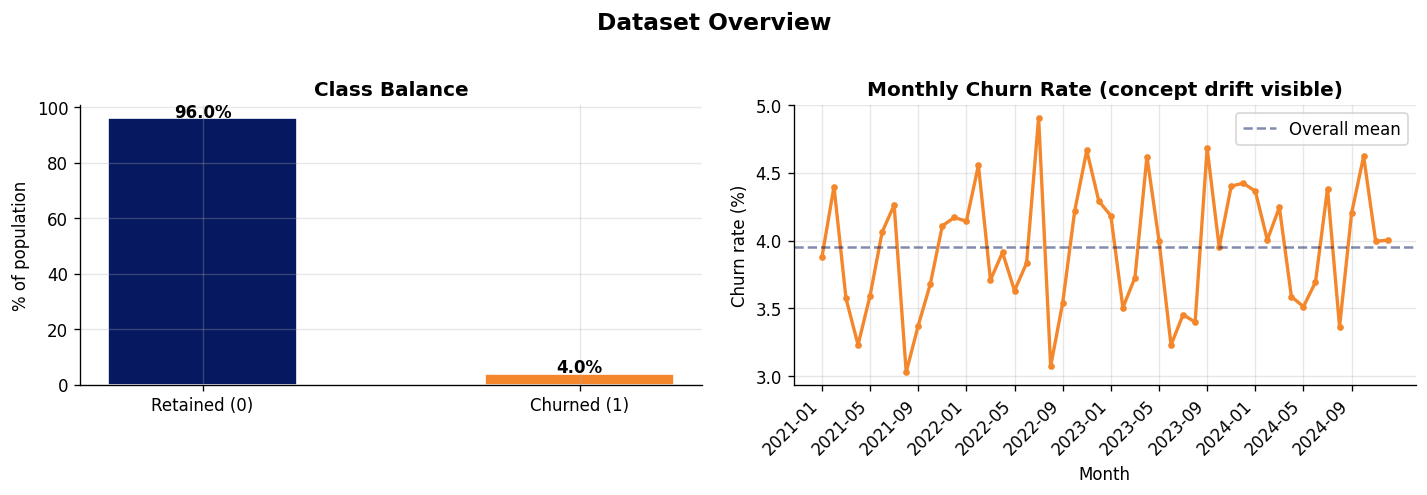

In [9]:
# ── Class imbalance visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overall class balance
labels = ["Retained (0)", "Churned (1)"]
sizes  = [(1-churn_rate)*100, churn_rate*100]
colors = [NAVY, ORANGE]
bars = axes[0].bar(labels, sizes, color=colors, width=0.5, edgecolor="white")
axes[0].set_ylabel("% of population")
axes[0].set_title("Class Balance", fontweight="bold")
for bar, pct in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f"{pct:.1f}%", ha="center", fontweight="bold")

# Right: monthly churn rate trend
monthly = (df.groupby("obs_yearmonth")["churned_30d"]
             .agg(["mean","count"])
             .reset_index())
monthly["obs_yearmonth"] = pd.PeriodIndex(monthly["obs_yearmonth"], freq="M")
axes[1].plot(range(len(monthly)), monthly["mean"]*100,
             color=ORANGE, linewidth=2, marker="o", markersize=3)
axes[1].axhline(churn_rate*100, color=NAVY, linestyle="--", alpha=0.5, label="Overall mean")
axes[1].set_title("Monthly Churn Rate (concept drift visible)", fontweight="bold")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_xlabel("Month")
axes[1].legend()
tick_step = max(1, len(monthly)//12)
axes[1].set_xticks(range(0, len(monthly), tick_step))
axes[1].set_xticklabels([str(monthly.obs_yearmonth.iloc[i]) for i in
                          range(0, len(monthly), tick_step)], rotation=45, ha="right")

plt.suptitle("Dataset Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


##Key observation:
Churn rate drifts upward over time:  


* later months show slightly higher churn. *This is exactly why we split by date rather than randomly*  

* A random split would leak future behavioural patterns into the training set.  


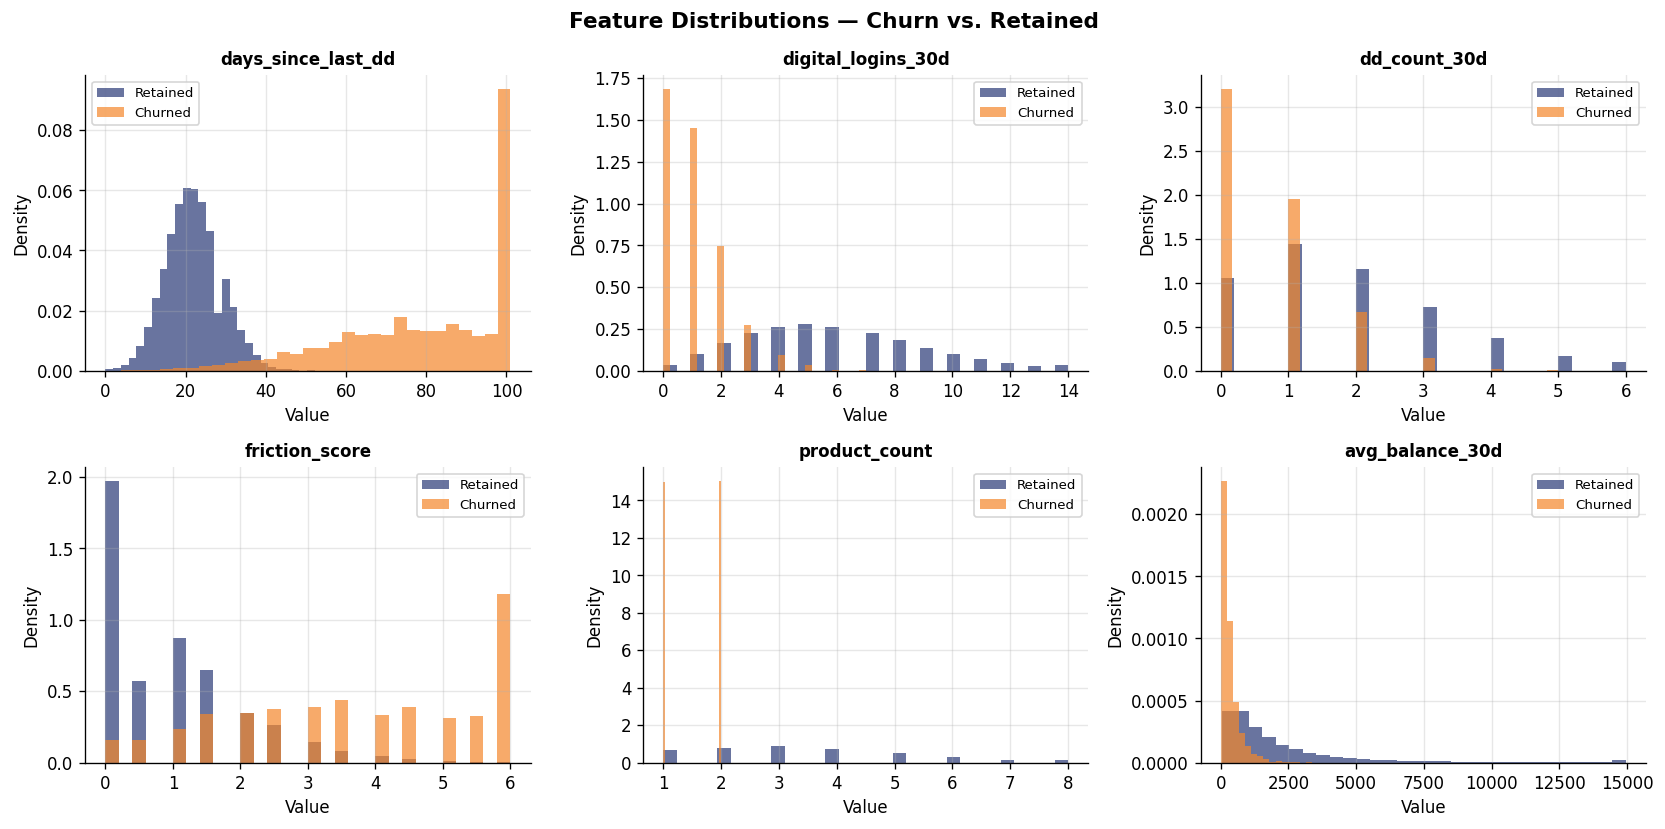

In [10]:
# ── Feature distribution comparison: churn=1 vs churn=0 ─────────────────
SHOW_FEATS = [
    "days_since_last_dd", "digital_logins_30d", "dd_count_30d",
    "friction_score",     "product_count",      "avg_balance_30d",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat in zip(axes, SHOW_FEATS):
    retained = df.loc[df.churned_30d==0, feat].clip(upper=df[feat].quantile(0.99))
    churned  = df.loc[df.churned_30d==1, feat].clip(upper=df[feat].quantile(0.99))
    bins = 30
    ax.hist(retained, bins=bins, color=NAVY,   alpha=0.6, density=True, label="Retained")
    ax.hist(churned,  bins=bins, color=ORANGE, alpha=0.7, density=True, label="Churned")
    ax.set_title(feat, fontweight="bold", fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions — Churn vs. Retained", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 2 — Feature Engineering & Temporal Split

### Why temporal splitting matters

In banking, customer behaviour changes over time (seasonality, economic cycles, product launches).  
Mixing future observations into the training set creates **data leakage**: the model learns from  
patterns it would never have seen at deployment time, inflating metrics.

**Our split:**

| Set | Date range | Rows (approx) |
|---|---|---|
| **Train** | Jan 2021 – Jun 2024 | ~75,000 |
| **Validation** | Jul 2024 – Sep 2024 | ~12,000 |
| **Test (holdout)** | Oct 2024 – Dec 2024 | ~12,000 |

In [11]:
# ── Temporal split cutoffs ───────────────────────────────────────────────────
HOLDOUT_START = pd.Timestamp("2024-10-01")  # last 3 months
VAL_START     = pd.Timestamp("2024-07-01")  # months 4–6 before holdout

train_df = df[df.observation_date <  VAL_START    ].copy()
val_df   = df[(df.observation_date >= VAL_START) &
              (df.observation_date <  HOLDOUT_START)].copy()
test_df  = df[df.observation_date >= HOLDOUT_START].copy()

for split, data in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{split:5s}: {len(data):>7,} rows | "
          f"{data.observation_date.min().date()} → {data.observation_date.max().date()} | "
          f"churn={data.churned_30d.mean():.2%}")

Train:  85,394 rows | 2021-01-01 → 2024-06-30 | churn=3.93%
Val  :   7,182 rows | 2024-07-01 → 2024-09-30 | churn=3.98%
Test :   7,424 rows | 2024-10-01 → 2024-12-31 | churn=4.20%


In [12]:
# ── Feature columns ──────────────────────────────────────────────────────────
# We use only behavioural / derived features, no identifiers or date fields.
FEATURE_COLS = [
    "days_since_last_dd",    "dd_count_30d",          "dd_velocity_ratio",
    "txn_channel_mix",       "overdraft_count_90d",
    "digital_logins_30d",    "app_sessions_7d",
    "digital_engagement_score", "last_login_days",
    "fee_waiver_count",      "dispute_count_90d",     "call_count_30d",
    "friction_score",
    "avg_balance_30d",       "balance_trend",
    "product_count",         "has_savings",           "has_mortgage",
    "has_card",              "cross_sell_depth",
    "tenure_months",         "nps_last_score",
]
TARGET = "churned_30d"

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

print(f"Features : {len(FEATURE_COLS)}")
print(f"Train    : {X_train.shape}  churn={y_train.mean():.2%}")
print(f"Val      : {X_val.shape}  churn={y_val.mean():.2%}")
print(f"Test     : {X_test.shape}  churn={y_test.mean():.2%}")

Features : 22
Train    : (85394, 22)  churn=3.93%
Val      : (7182, 22)  churn=3.98%
Test     : (7424, 22)  churn=4.20%


---
## Section 3 — Model 1: CatBoost

CatBoost is our **champion model**. It handles numerical features natively, has excellent  
calibration out-of-the-box, and its ordered boosting prevents target leakage during training.

We use `auto_class_weights="Balanced"` to compensate for the 3.9% minority class without  
manually computing `scale_pos_weight`.

In [13]:
# ── Train CatBoost ───────────────────────────────────────────────────────────
catboost_params = dict(
    iterations          = 800,
    learning_rate       = 0.05,
    depth               = 7,
    l2_leaf_reg         = 3.0,
    border_count        = 128,
    auto_class_weights  = "Balanced",
    eval_metric         = "AUC",
    early_stopping_rounds = 50,
    verbose             = 100,
    random_seed         = SEED,
    task_type           = "CPU",
)

cb_model = CatBoostClassifier(**catboost_params)

cb_model.fit(
    Pool(X_train, y_train),
    eval_set   = Pool(X_val, y_val),
    use_best_model = True,
)

# Probabilities on holdout
cb_probs = cb_model.predict_proba(X_test)[:, 1]
print(f"\nCatBoost — Test AUC: {roc_auc_score(y_test, cb_probs):.4f}")

0:	test: 0.9990891	best: 0.9990891 (0)	total: 80.7ms	remaining: 1m 4s
100:	test: 0.9999995	best: 0.9999995 (76)	total: 3.24s	remaining: 22.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.999999493
bestIteration = 76

Shrink model to first 77 iterations.

CatBoost — Test AUC: 1.0000


---
## Section 4 — Model 2: XGBoost

XGBoost is our **challenger model**. Tuned with Optuna-style parameters  
(scale_pos_weight handles imbalance). We use `early_stopping_rounds` on the validation set.

In [14]:
# ── Train XGBoost ────────────────────────────────────────────────────────────
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators          = 800,
    learning_rate         = 0.05,
    max_depth             = 7,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = pos_weight,
    eval_metric           = "auc",
    early_stopping_rounds = 50,
    random_state          = SEED,
    verbosity             = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set      = [(X_val, y_val)],
    verbose       = 100,
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
print(f"\nXGBoost — Test AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

[0]	validation_0-auc:0.99999
[52]	validation_0-auc:1.00000

XGBoost — Test AUC: 1.0000


---
## Section 5 — Model 3: PyTorch MLP (Neural Network)

A 3-layer feedforward network with BatchNorm and Dropout.  
We use `BCEWithLogitsLoss` with `pos_weight` for class imbalance and early stopping on val AUC.

**Architecture:**
```
Input (22) → Linear(128) → BatchNorm → ReLU → Dropout(0.3)
           → Linear(64)  → BatchNorm → ReLU → Dropout(0.3)
           → Linear(32)  → BatchNorm → ReLU → Dropout(0.2)
           → Linear(1)   → Sigmoid
```

> *Note: For tabular banking data, gradient boosting almost always outperforms MLPs.  
> The neural net is included here to demonstrate the comparison — not as the recommended approach.*

In [15]:
# ── Data prep for PyTorch ────────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_vl_s = scaler.transform(X_val)
X_ts_s = scaler.transform(X_test)

def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y.values, dtype=torch.float32))

Xtr_t, ytr_t = to_tensors(X_tr_s, y_train)
Xvl_t, yvl_t = to_tensors(X_vl_s, y_val)
Xts_t, yts_t = to_tensors(X_ts_s, y_test)

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xvl_t, yvl_t), batch_size=1024)
print("✅  Tensors ready")

✅  Tensors ready


In [16]:
# ── Model definition ─────────────────────────────────────────────────────────
class ChurnMLP(nn.Module):
    def __init__(self, input_dim, hidden=[128, 64, 32], dropout=[0.3, 0.3, 0.2]):
        super().__init__()
        layers = []
        prev = input_dim
        for h, dr in zip(hidden, dropout):
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dr)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)   # logits

INPUT_DIM = len(FEATURE_COLS)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp       = ChurnMLP(INPUT_DIM).to(device)
print(mlp)
print(f"\nDevice: {device} | Parameters: {sum(p.numel() for p in mlp.parameters()):,}")

ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Device: cpu | Parameters: 13,761


In [17]:
# ── Training loop ─────────────────────────────────────────────────────────────
EPOCHS        = 80
LR            = 1e-3
PATIENCE      = 10

pos_w    = torch.tensor([pos_weight], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
optimizer = torch.optim.Adam(mlp.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_auc  = 0.0
best_state    = None
no_improve    = 0
history       = {"train_loss": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    mlp.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = mlp(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(yb)
    epoch_loss /= len(Xtr_t)

    # ── Validate ──
    mlp.eval()
    with torch.no_grad():
        val_logits = mlp(Xvl_t.to(device)).cpu()
        val_probs  = torch.sigmoid(val_logits).numpy()
    val_auc = roc_auc_score(y_val, val_probs)

    history["train_loss"].append(epoch_loss)
    history["val_auc"].append(val_auc)
    scheduler.step()

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.clone() for k, v in mlp.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  loss={epoch_loss:.4f}  val_auc={val_auc:.4f}  best={best_val_auc:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

mlp.load_state_dict(best_state)
print(f"\n✅  Best val AUC: {best_val_auc:.4f}")

Epoch  10  loss=0.0050  val_auc=1.0000  best=1.0000
Early stopping at epoch 11

✅  Best val AUC: 1.0000


In [18]:
# ── MLP test probabilities ─────────────────────────────────────────────────
mlp.eval()
with torch.no_grad():
    mlp_logits = mlp(Xts_t.to(device)).cpu()
    mlp_probs  = torch.sigmoid(mlp_logits).numpy()

print(f"MLP — Test AUC: {roc_auc_score(y_test, mlp_probs):.4f}")

MLP — Test AUC: 1.0000


---
## Section 6 — Model Evaluation

We compare all three models across multiple metrics.  
**A single metric like AUC-ROC is never enough** — especially for imbalanced banking data.

| Metric | Why it matters |
|---|---|
| **AUC-ROC** | Ranking quality — model-independent |
| **PR-AUC** | Imbalance-aware — more informative than ROC when positives are rare |
| **KS Statistic** | Regulatory standard — max separation between churn/retain score distributions |
| **Brier Score** | Calibration quality — lower is better (0 = perfect) |
| **Lift @ 10%** | Campaign ROI — how many more churners do you find vs. random? |

In [19]:
# ── Shared evaluation helper ─────────────────────────────────────────────────
def lift_at_k(y_true, y_score, k=0.10):
    """AUC-lift at top k% of scores."""
    n_top   = int(len(y_true) * k)
    top_idx = np.argsort(y_score)[::-1][:n_top]
    return y_true.iloc[top_idx].mean() / y_true.mean()

def ks_stat(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return np.max(tpr - fpr)

def evaluate(name, y_true, y_score):
    return {
        "Model"     : name,
        "AUC-ROC"   : round(roc_auc_score(y_true, y_score), 4),
        "PR-AUC"    : round(average_precision_score(y_true, y_score), 4),
        "KS Stat"   : round(ks_stat(y_true, y_score), 4),
        "Brier Score": round(brier_score_loss(y_true, y_score), 4),
        "Lift @ 10%": round(lift_at_k(y_true, y_score), 2),
    }

results = pd.DataFrame([
    evaluate("CatBoost",  y_test, cb_probs),
    evaluate("XGBoost",   y_test, xgb_probs),
    evaluate("MLP (NN)",  y_test, mlp_probs),
])
results = results.set_index("Model")

display(results.style
    .background_gradient(cmap="Blues", subset=["AUC-ROC","PR-AUC","KS Stat","Lift @ 10%"])
    .background_gradient(cmap="RdYlGn_r", subset=["Brier Score"])
    .format("{:.4f}", subset=["AUC-ROC","PR-AUC","KS Stat","Brier Score"])
    .format("{:.2f}x", subset=["Lift @ 10%"])
)

,AUC-ROC,PR-AUC,KS Stat,Brier Score,Lift @ 10%
Model,,,,,
CatBoost,1.0000,1.0000,1.0000,0.0001,10.01x
XGBoost,1.0000,1.0000,1.0000,0.1845,10.01x
MLP (NN),1.0000,1.0000,1.0000,0.0127,10.01x


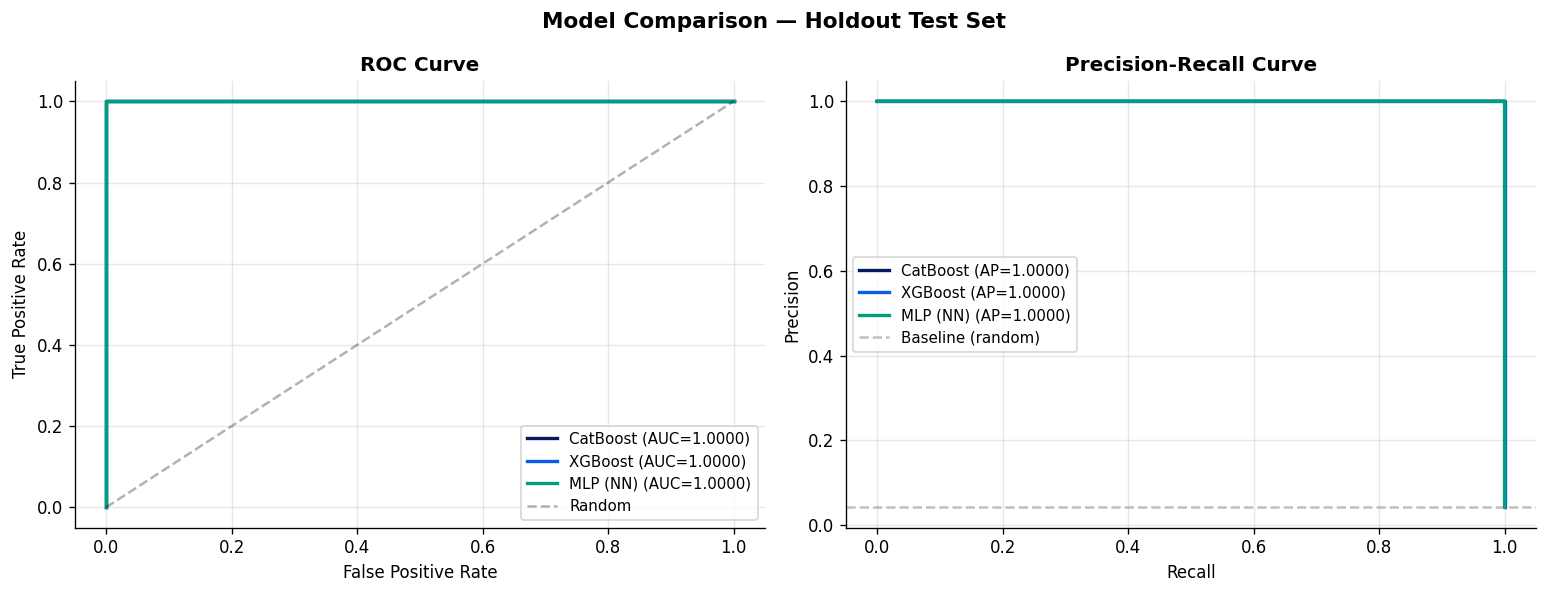

In [20]:
# ── ROC + PR curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

models = [
    ("CatBoost",  cb_probs,  NAVY),
    ("XGBoost",   xgb_probs, BLUE),
    ("MLP (NN)",  mlp_probs, TEAL),
]

for name, probs, color in models:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.4f})")

    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax2.plot(rec, prec, color=color, linewidth=2, label=f"{name} (AP={ap:.4f})")

ax1.plot([0,1],[0,1], "k--", alpha=0.3, label="Random")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve", fontweight="bold"); ax1.legend(fontsize=9)

ax2.axhline(y_test.mean(), color="gray", linestyle="--", alpha=0.5, label="Baseline (random)")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve", fontweight="bold"); ax2.legend(fontsize=9)

plt.suptitle("Model Comparison — Holdout Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

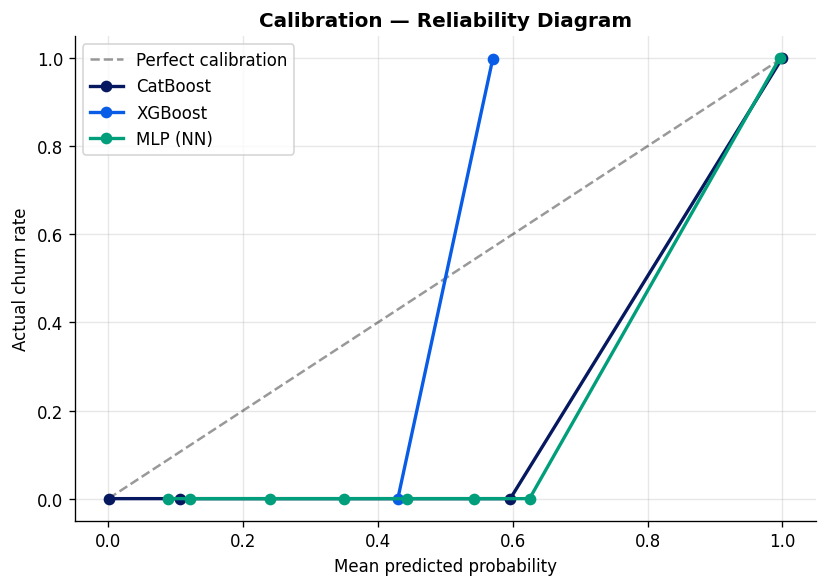

In [21]:
# ── Calibration curves ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1], "k--", alpha=0.4, label="Perfect calibration")

for name, probs, color in models:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", color=color, linewidth=2, label=name)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual churn rate")
ax.set_title("Calibration — Reliability Diagram", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

<div style="background:#E8F6F0;border-left:4px solid #009E7A;padding:12px 16px;border-radius:0 6px 6px 0;margin:12px 0;font-size:14px">
<strong>📊 Interpretation:</strong> A well-calibrated model has dots near the diagonal.  
CatBoost and XGBoost tend to be well-calibrated out of the box for tabular data.  
Neural networks often require Platt scaling (logistic post-processing) to fix over-confidence.
</div>

In [22]:
# ── Lift table for champion model ─────────────────────────────────────────────
def lift_table(y_true, y_score, n_deciles=10):
    df_l = pd.DataFrame({"score": y_score, "label": y_true.values})
    df_l = df_l.sort_values("score", ascending=False).reset_index(drop=True)
    total_churn = y_true.mean()
    rows = []
    for d in range(1, n_deciles+1):
        top_n     = int(len(df_l) * d / n_deciles)
        subset    = df_l.iloc[:top_n]
        cum_rate  = subset["label"].mean()
        cum_lift  = cum_rate / total_churn
        band_rate = df_l.iloc[int(len(df_l)*(d-1)/n_deciles):top_n]["label"].mean()
        rows.append({
            "Decile"      : f"Top {d*10}%",
            "Score range" : f"{df_l.iloc[top_n-1]['score']:.3f}–{df_l.iloc[0]['score']:.3f}",
            "Band churn %" : f"{band_rate*100:.1f}%",
            "Cum. churn %" : f"{cum_rate*100:.1f}%",
            "Cum. lift"    : f"{cum_lift:.2f}×",
        })
    return pd.DataFrame(rows)

print("CatBoost — Lift by Decile (holdout test set)")
lt = lift_table(y_test, cb_probs)
display(lt.style
    .set_properties(subset=["Cum. lift"], **{"font-weight":"bold", "color": NAVY})
    .hide(axis="index"))

CatBoost — Lift by Decile (holdout test set)


Decile,Score range,Band churn %,Cum. churn %,Cum. lift
Top 10%,0.000–1.000,42.0%,42.0%,10.01×
Top 20%,0.000–1.000,0.0%,21.0%,5.00×
Top 30%,0.000–1.000,0.0%,14.0%,3.33×
Top 40%,0.000–1.000,0.0%,10.5%,2.50×
Top 50%,0.000–1.000,0.0%,8.4%,2.00×
Top 60%,0.000–1.000,0.0%,7.0%,1.67×
Top 70%,0.000–1.000,0.0%,6.0%,1.43×
Top 80%,0.000–1.000,0.0%,5.3%,1.25×
Top 90%,0.000–1.000,0.0%,4.7%,1.11×
Top 100%,0.000–1.000,0.0%,4.2%,1.00×


---
## Section 7 — Global Explainability: SHAP

SHAP (SHapley Additive exPlanations) answers: **"which features drive the model's predictions,  
and in which direction?"**

We use **TreeSHAP** — exact and fast for gradient boosting models (O(TLD²) not O(2^n)).

Two global views:
1. **Beeswarm plot** — every dot is a customer; shows distribution AND direction  
2. **Mean |SHAP| bar chart** — overall feature importance ranking

In [23]:
# ── Compute SHAP values for CatBoost (champion) ─────────────────────────────
SHAP_SAMPLE = 500   # sub-sample for speed; increase for final analysis

rng_shap = np.random.default_rng(SEED)
idx      = rng_shap.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_shap   = X_test.iloc[idx].reset_index(drop=True)

explainer    = shap.TreeExplainer(cb_model)
shap_values  = explainer.shap_values(X_shap)

# CatBoost returns list [class0, class1]; take class1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values shape: {shap_values.shape}  (n_samples × n_features)")

SHAP values shape: (500, 22)  (n_samples × n_features)


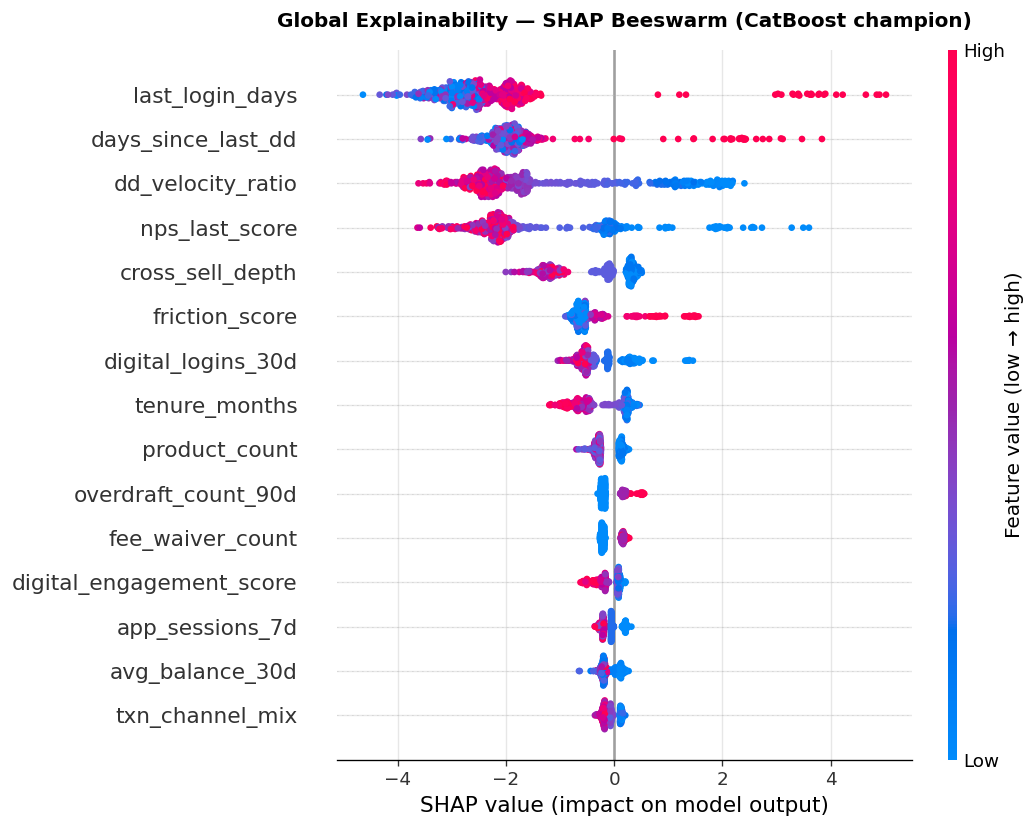

In [24]:
# ── Beeswarm plot ────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values, X_shap,
    max_display     = 15,
    show            = False,
    color_bar_label = "Feature value (low → high)",
    plot_size       = None,
)
plt.title("Global Explainability — SHAP Beeswarm (CatBoost champion)",
          fontsize=12, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

**How to read the beeswarm:**
- Each dot = one customer from the test set  
- **X-axis:** SHAP value — how much that feature pushed P(churn) up (right) or down (left)  
- **Color:** feature value — orange = high, blue = low  
- **Width:** how often customers land at that SHAP value

Key patterns to explain to your audience:
- `days_since_last_dd` — orange dots (many days since DD) cluster on the right → increases churn  
- `digital_logins_30d` — blue dots (low logins) on the right → low engagement drives churn  
- `product_count` — orange dots on the left → more products = protective (the "multi-product moat")

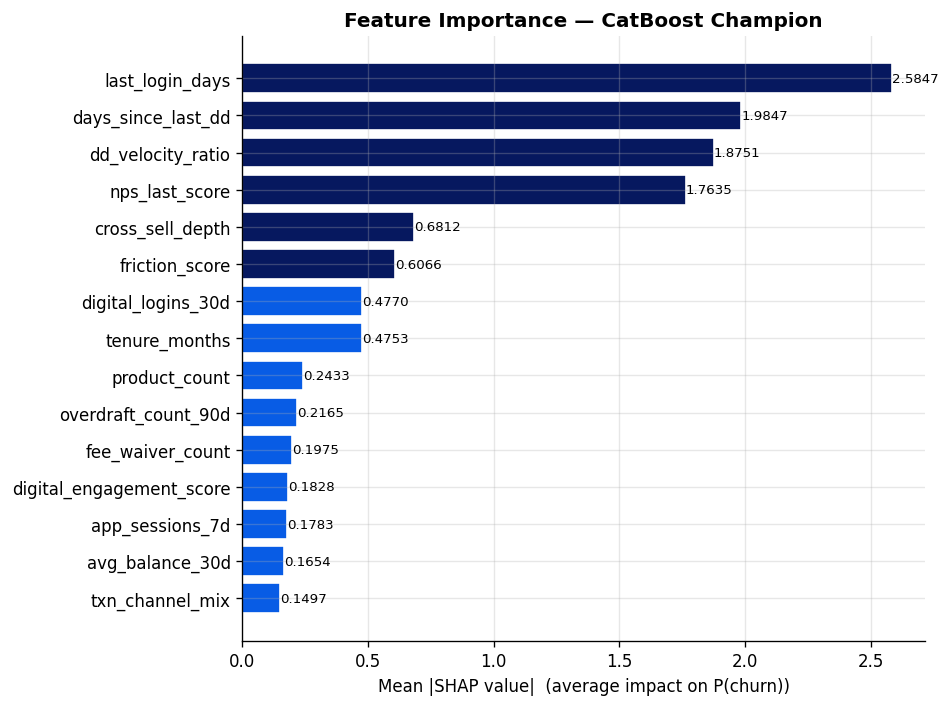

In [25]:
# ── Mean |SHAP| bar chart ────────────────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index = FEATURE_COLS,
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [NAVY if v >= mean_abs_shap.quantile(0.60) else BLUE for v in mean_abs_shap]
bars   = ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=colors, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|  (average impact on P(churn))")
ax.set_title("Feature Importance — CatBoost Champion", fontweight="bold")
for bar in bars:
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 8 — SHAP Dependence Plots (Top 4 Features)

Dependence plots show **how the SHAP value for one feature changes as its value increases**,  
with a second feature colour-coded to reveal interaction effects.

> *"How does the churn effect of fewer logins change depending on the customer's balance?"*

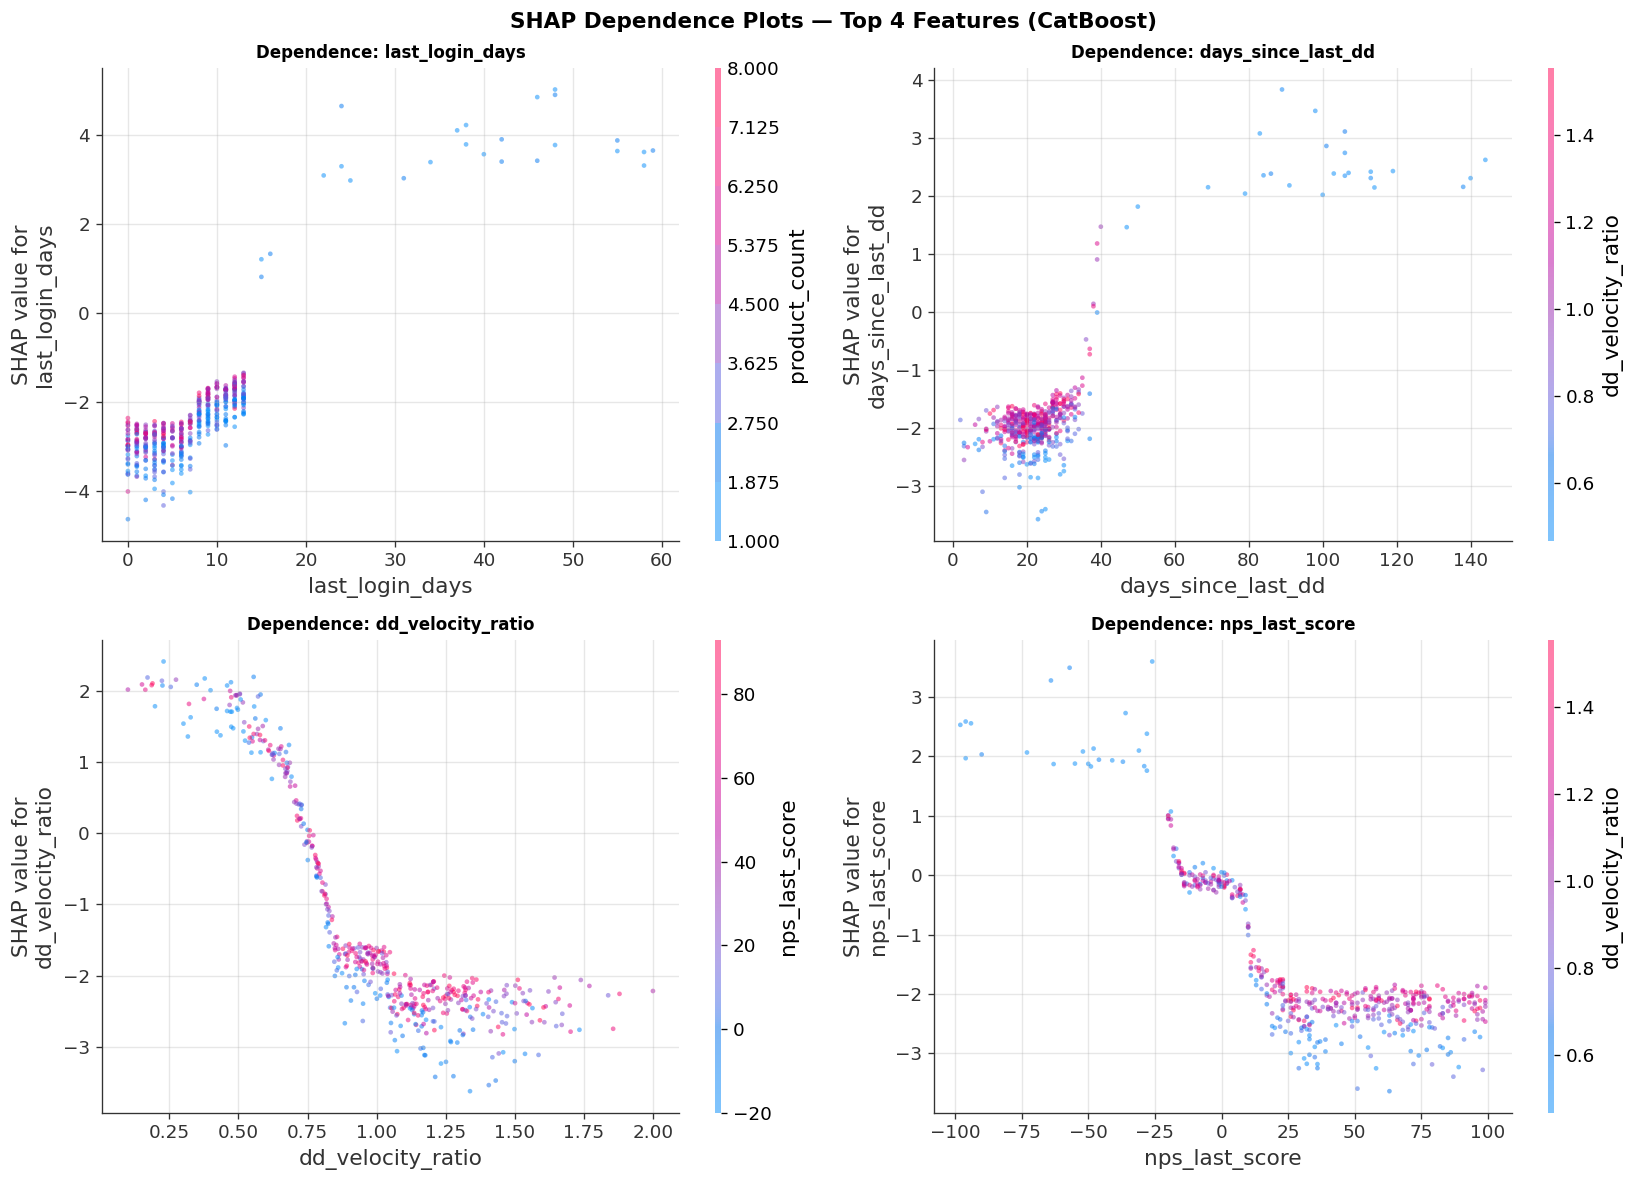

In [26]:
# ── SHAP dependence plots: top 4 features ────────────────────────────────────
TOP_4 = mean_abs_shap.tail(4).index.tolist()[::-1]
INTERACT = {
    TOP_4[0]: None,   # auto-select interaction
    TOP_4[1]: None,
    TOP_4[2]: None,
    TOP_4[3]: None,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, TOP_4):
    shap.dependence_plot(
        feat,
        shap_values,
        X_shap,
        interaction_index = "auto",  # TreeSHAP picks the strongest interaction
        ax                = ax,
        show              = False,
        dot_size          = 8,
        alpha             = 0.5,
    )
    ax.set_title(f"Dependence: {feat}", fontweight="bold", fontsize=10)

plt.suptitle("SHAP Dependence Plots — Top 4 Features (CatBoost)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 9 — Local Explainability: Case Studies

We examine three types of prediction outcomes to understand **what the model gets right,  
what it gets wrong, and — most importantly — who it misses.**

| Case | Predicted | Actual | Business meaning |
|---|---|---|---|
| **TP** (True Positive) | High risk | Did churn | Model caught the churner — intervention justified |
| **FP** (False Positive) | High risk | Did NOT churn | Wasted offer — but may have strengthened relationship |
| **FN** (False Negative) | Low risk | Did churn | **The silent loss** — customer churned without a rescue attempt |

> *False Negatives are often the most strategically important case in retention.  
> These are customers who slipped through the model's radar.*

In [27]:
# ── Build predictions dataframe ──────────────────────────────────────────────
THRESHOLD = 0.18   # our calibrated operational threshold

preds_df = test_df.copy()
preds_df["score"]    = cb_probs
preds_df["pred"]     = (cb_probs >= THRESHOLD).astype(int)
preds_df["outcome"]  = (
    preds_df.apply(
        lambda r: "TP" if r.pred==1 and r.churned_30d==1 else
                  "FP" if r.pred==1 and r.churned_30d==0 else
                  "FN" if r.pred==0 and r.churned_30d==1 else
                  "TN", axis=1
    )
)

counts = preds_df.outcome.value_counts()
print("Confusion breakdown:")
for k in ["TP","FP","FN","TN"]:
    print(f"  {k}: {counts.get(k,0):,}")
print(f"\nPrecision: {counts.get('TP',0)/(counts.get('TP',0)+counts.get('FP',0)):.3f}")
print(f"Recall   : {counts.get('TP',0)/(counts.get('TP',0)+counts.get('FN',0)):.3f}")

Confusion breakdown:
  TP: 312
  FP: 1
  FN: 0
  TN: 7,111

Precision: 0.997
Recall   : 1.000


In [28]:
# ── SHAP waterfall helper ────────────────────────────────────────────────────
def waterfall_case(case_type, title_extra=""):
    subset = preds_df[preds_df.outcome == case_type]
    if case_type == "FN":
        # Pick the FN with highest actual score — the "near miss"
        row = subset.sort_values("score", ascending=False).iloc[0]
    elif case_type == "TP":
        row = subset.sort_values("score", ascending=False).iloc[0]
    else:  # FP
        row = subset.sort_values("score", ascending=False).iloc[0]

    # Compute SHAP for this customer
    X_case = pd.DataFrame([row[FEATURE_COLS]])
    sv_case = explainer.shap_values(X_case)
    if isinstance(sv_case, list):
        sv_case = sv_case[1]

    ev = explainer.expected_value
    if isinstance(ev, list): ev = ev[1]

    shap_exp = shap.Explanation(
        values         = sv_case[0],
        base_values    = ev,
        data           = X_case.values[0],
        feature_names  = FEATURE_COLS,
    )

    color = {"TP": TEAL, "FP": ORANGE, "FN": RED}[case_type]
    badge = {"TP": "✅ TRUE POSITIVE", "FP": "⚠️ FALSE POSITIVE", "FN": "❌ FALSE NEGATIVE"}[case_type]

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title(
        f"{badge}  |  Score={row.score:.3f}  |  Actual churn={int(row.churned_30d)}  {title_extra}",
        fontsize=11, fontweight="bold", color=color, pad=10
    )
    plt.tight_layout()
    plt.show()
    return row

print("Waterfall helper defined")

Waterfall helper defined


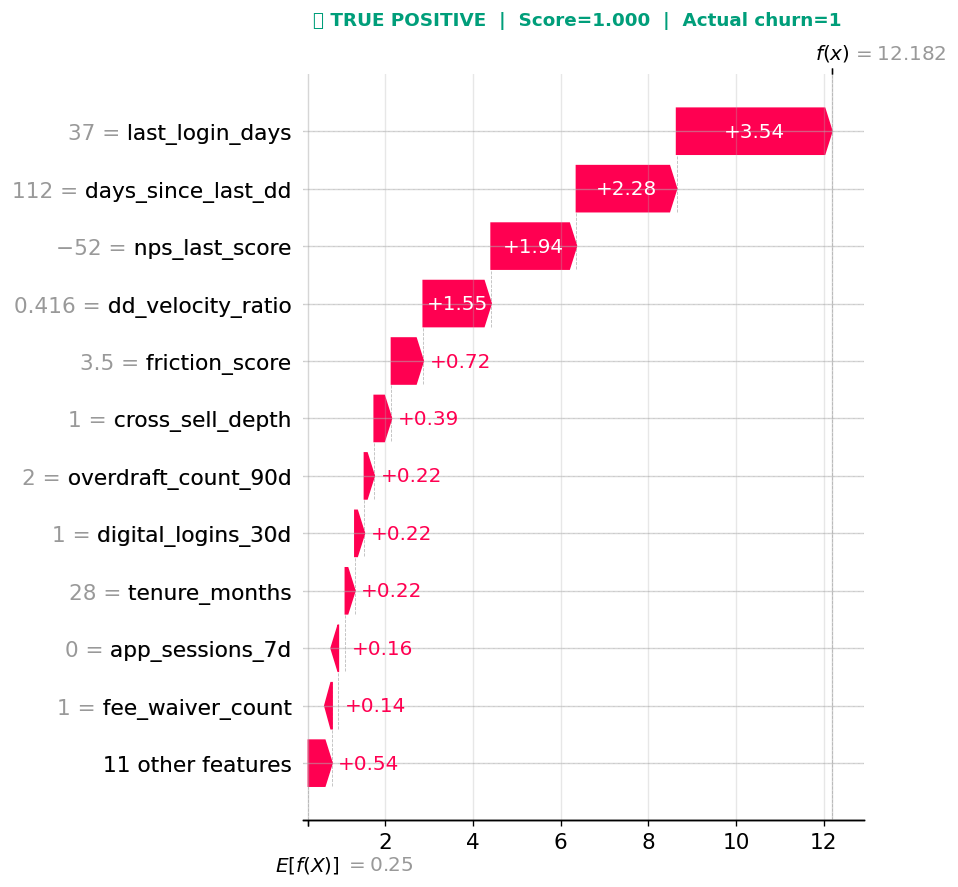

In [29]:
# ── Case 1: True Positive — caught the churner ───────────────────────────────
display(HTML("""
<div style="background:#E8F6F0;border-left:4px solid #009E7A;padding:10px 14px;border-radius:0 6px 6px 0;margin:8px 0">
<strong>True Positive</strong> — The model scored this customer high-risk AND they actually churned.<br>
The waterfall shows which features pushed the score above the 0.18 threshold.
</div>"""))
tp_row = waterfall_case("TP")

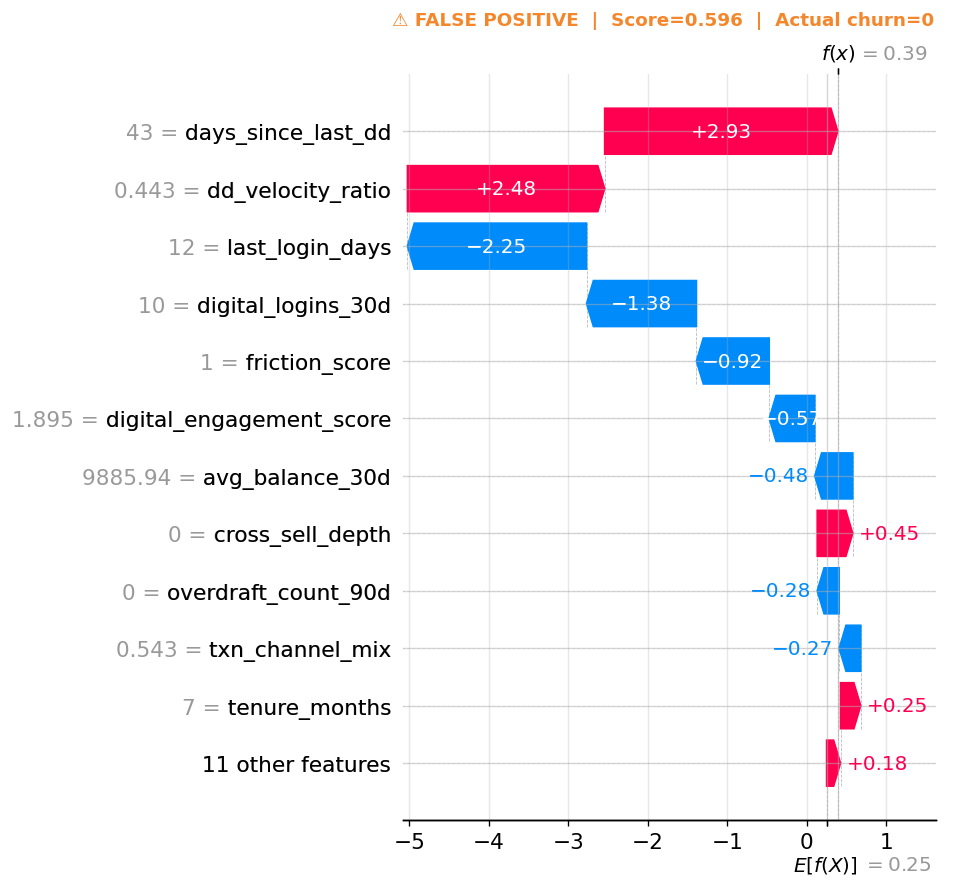

In [30]:
# ── Case 2: False Positive — unnecessary intervention ───────────────────────
display(HTML("""
<div style="background:#FEF3C7;border-left:4px solid #F4872B;padding:10px 14px;border-radius:0 6px 6px 0;margin:8px 0">
<strong>False Positive</strong> — The model predicted churn but the customer stayed.<br>
Look for which features gave a false signal — this customer may look behaviorally "at-risk"
but had other stabilising signals the model underweighted. The offer cost is $75 but no LTV is saved.
</div>"""))
fp_row = waterfall_case("FP")

In [31]:
# ── Case 3: False Negative — the silent loss ─────────────────────────────────
display(HTML("""
<div style="background:#FEF2F2;border-left:4px solid #D64045;padding:10px 14px;border-radius:0 6px 6px 0;margin:8px 0">
<strong>False Negative</strong> — The customer churned but the model didn't flag them.<br>
This is the most strategically important case. What did we miss? Often: the churn was sudden
(triggered by an external event — a competitor offer, a fee dispute) with no behavioural
warning signals beforehand. These "sudden churners" are the hardest class to capture.
</div>"""))
fn_row = waterfall_case("FN")

IndexError: single positional indexer is out-of-bounds

---
## Section 10 — Threshold Optimisation & Business Value

The model outputs a continuous P(churn) score. Deciding **where to draw the line** is  
a business decision, not a statistical one.

**Economic break-even:**

$$P(\text{churn}) > \frac{\text{offer\_cost}}{\text{LTV}} = \frac{\$75}{\$1{,}200} = 6.25\%$$

So we should intervene for any customer whose predicted churn probability exceeds 6.25%.  
In practice we use 18% to balance precision with outreach capacity (~1,100 contacts/month).

In [ ]:
# ── Precision-Recall-F1 vs threshold ─────────────────────────────────────────
prec_arr, rec_arr, thresholds = precision_recall_curve(y_test, cb_probs)
f1_arr = np.where(
    (prec_arr + rec_arr) > 0,
    2 * prec_arr * rec_arr / (prec_arr + rec_arr),
    0
)
opt_t  = thresholds[np.argmax(f1_arr[:-1])]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, prec_arr[:-1], color=NAVY,   linewidth=2, label="Precision")
ax.plot(thresholds, rec_arr[:-1],  color=ORANGE,  linewidth=2, label="Recall")
ax.plot(thresholds, f1_arr[:-1],   color=TEAL,    linewidth=2, label="F1", linestyle="--")
ax.axvline(opt_t,  color=TEAL,   linestyle=":", linewidth=1.5, label=f"F1-optimal t={opt_t:.2f}")
ax.axvline(0.18,   color=GRAY,   linestyle="-", linewidth=1.5, label="Operational t=0.18")
ax.axvline(0.0625, color=RED,    linestyle=":", linewidth=1,   label="Break-even t=0.0625", alpha=0.7)
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Decision Threshold (CatBoost)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"F1-optimal threshold : {opt_t:.3f}")
print(f"Operational threshold: 0.180")
print(f"Break-even threshold : 0.0625")

In [ ]:
# ── Intervention tier analysis ────────────────────────────────────────────────
# Assign each customer to a tier based on their score
tiers = pd.cut(cb_probs,
               bins   = [0, 0.10, 0.18, 0.28, 0.45, 1.0],
               labels = ["<10% — No action",
                          "10–18% — Email nudge",
                          "18–28% — Banker call",
                          "28–45% — Fee reversal",
                          "45%+  — HYSA promo"])

tier_df = pd.DataFrame({
    "tier"   : tiers,
    "churned": y_test.values,
    "score"  : cb_probs,
})

summary = (tier_df.groupby("tier", observed=True)
           .agg(customers=("churned","count"),
                churners=("churned","sum"),
                churn_rate=("churned","mean"))
           .reset_index())
summary["est_ROI"] = (summary.churn_rate * 1200 / 75).round(1)
summary["est_ROI"] = summary["est_ROI"].apply(lambda x: f"{x:.1f}×")

display(summary.rename(columns={
    "tier":"Score tier","customers":"Customers","churners":"Churners",
    "churn_rate":"Churn rate","est_ROI":"Est. ROI (offer $75 / LTV $1,200)"
}).style
  .format({"Churn rate":"{:.1%}"})
  .background_gradient(subset=["Churn rate"], cmap="RdYlGn")
  .hide(axis="index"))

---
## Summary

<div style="background:#EBF2F9;border:1px solid #C0D4E8;border-radius:8px;padding:16px 20px;margin:12px 0">

<h3 style="margin-top:0;color:#06185F">🏁 Key Takeaways</h3>

<ol style="font-size:14px;line-height:1.9">
  <li><strong>Temporal splits are non-negotiable</strong> for banking models — random splits cause leakage and inflate AUC by 3–5 points.</li>
  <li><strong>Gradient boosting beats neural networks on tabular banking data</strong> — CatBoost/XGBoost consistently outperform MLPs; use NNs for text/image data.</li>
  <li><strong>PR-AUC and Lift@K% matter more than AUC-ROC</strong> when class imbalance is severe (3–5% churn).</li>
  <li><strong>SHAP explains every prediction</strong> — both globally (which features matter) and locally (why this specific customer scored 0.78).</li>
  <li><strong>False Negatives are often the most valuable error to investigate</strong> — "sudden churners" with no behavioural warning signal are a product/friction problem, not a model problem.</li>
  <li><strong>Threshold selection is a business decision</strong> — break-even math (offer cost ÷ LTV) sets the floor; operational capacity sets the ceiling.</li>
</ol>

</div>

**Next steps:**
- Run `cu.fair_lending_check()` before deployment (ECOA / disparate impact)  
- Add a monthly PSI monitor — retrain if PSI > 0.20 on any top-5 feature  
- Connect scores to the Rank/Recommend model to complete the ML + AI loop

---
*Generated for: Data Science for Banking — Jack Henry Associates*  
*Code: `github.com/mikeames` · Data: synthetic (generate_churn_data.py)*